<a href="https://colab.research.google.com/github/santoprestandrea/bottle-anomaly-detection-project/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.__version__)
print(torch.cuda.get_device_name(0))

True
2.10.0+cu128
Tesla T4


In [2]:
import os
import glob
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from tqdm import tqdm # barra di progresso -> se devo aspettare 30s, invece di aspettare nel vuoto vedo una barra che avanza

torch.manual_seed(42) # queste 3 righe servono per rendere i risultati riproducibili, in modo che ogni volta che eseguo il codice ottengo gli stessi risultati
np.random.seed(42)
random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


# Section 1 — The Problem: Industrial Anomaly Detection

## Problem Statement

In manufacturing, **quality control** is the process of identifying defective products before they reach customers. Traditionally this task is performed by human inspectors, an approach that is costly, slow, and prone to inconsistency — particularly for high-throughput production lines.

This project addresses the automation of quality control through Computer Vision. The goal is to detect **visual anomalies** (scratches, fractures, contamination, deformations) in product images, using a pipeline that requires no manual inspection.

---

## The Core Challenge: One-Class Learning

Standard supervised classification requires labeled examples of *both* classes — in this case, both normal and defective products. In a real industrial setting, however, defective items are rare by design: a well-functioning production line produces very few of them. As a result, collecting a balanced labeled dataset of defects is impractical.

This project instead adopts a **one-class learning** strategy:

> Learn a representation of what a *normal* product looks like. At test time, flag any image that deviates significantly from that representation as anomalous.

No defective images are used during training. The model is exposed only to normal samples, and anomaly detection emerges from measuring deviation from the learned normality.

---

## Approach

The pipeline implements a simplified version of **PatchCore** (Roth et al., 2022), structured in four stages:

1. **Feature Extraction** — A pre-trained ResNet18 backbone is used to extract spatial feature maps from each training image. Rather than using a global descriptor, features are extracted at the patch level, preserving spatial localization.
2. **Memory Bank Construction** — All patch-level feature vectors extracted from normal training images are stored in a memory bank, forming a complete reference of known normal local appearances.
3. **Anomaly Scoring** — For each test image, the distance of each patch descriptor to its nearest neighbors in the memory bank is computed. A high distance indicates that the local appearance is unusual with respect to the normal distribution.
4. **Post-processing** — Raw anomaly maps are smoothed, upsampled to the original image resolution, and thresholded to produce pixel-level defect segmentation masks.
---

## Dataset: MVTec Anomaly Detection

The **MVTec AD dataset** (Bergmann et al., 2019) is the standard benchmark for industrial anomaly detection research. It contains 15 categories of objects and textures, each with:

- A **training set** composed exclusively of defect-free images.
- A **test set** containing both normal images and images with multiple defect types.
- **Pixel-level ground truth masks** for all defective test images.
This project uses the **bottle** category:

| Split | Content | Count |
|-------|---------|-------|
| Train | Normal images only | ~209 |
| Test — normal | Defect-free bottles | ~20 |
| Test — defective | `broken_large`, `broken_small`, `contamination` | ~63 |

Images have an original resolution of 900×900 pixels and are resized to 224×224 for processing.


In [3]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
# In Google Colab, files saved locally disappear when the session ends.
# To use a dataset uploaded to Google Drive we "mount" it:
# this makes it accessible as if it were a local folder on the machine.
from google.colab import drive
drive.mount("/content/drive")  # /content/drive will be the access point to Drive


DATASET_ROOT = "/content/drive/MyDrive/bottle"

# ── Configuration ─────────────────────────────────────────────────────────────
# All images will be resized to 224x224 pixels.
# This is the standard input size for ResNet18 (the network we will use).
IMAGE_SIZE = 224

# 'assert' is a sanity check: if the condition is False, it raises an error with the given message.
# os.path.isdir() checks whether the path exists and is a directory.
# This lets us catch a wrong dataset path immediately.
assert os.path.isdir(DATASET_ROOT), f"Dataset not found at: {DATASET_ROOT}"
print(f"Dataset found: {DATASET_ROOT}")

# os.listdir() returns a list with the names of files and folders inside the given path
print("Contents:", os.listdir(DATASET_ROOT))

Mounted at /content/drive
Dataset found: /content/drive/MyDrive/bottle
Contents: ['license.txt', 'readme.txt', 'train', 'test', 'ground_truth']


In [4]:
# ── Build paths to the dataset sub-folders ────────────────────────────────────
# os.path.join() concatenates path segments correctly for the operating system
# (uses / on Linux/Mac, \ on Windows automatically)
train_dir   = os.path.join(DATASET_ROOT, "train", "good")   # normal training images
test_dir    = os.path.join(DATASET_ROOT, "test")             # root folder of the test set

# ── Count images per category ─────────────────────────────────────────────────
# List comprehension: [expression for item in list if condition]
# A compact way to build a filtered list from another list.
# Here: take sub-folder names from the test directory, excluding "good" (the normal class)
defect_types = sorted([d for d in os.listdir(test_dir) if d != "good"])
# sorted() orders the list alphabetically

# glob.glob() finds all files matching a pattern; "*.png" = every .png file
# len() counts how many elements are in the resulting list
n_train        = len(glob.glob(os.path.join(train_dir, "*.png")))
n_test_normal  = len(glob.glob(os.path.join(test_dir, "good", "*.png")))

# Count defective images by summing across every defect type
# This is a "generator expression": like a list comprehension but more memory-efficient
n_test_defect  = sum(
    len(glob.glob(os.path.join(test_dir, d, "*.png"))) for d in defect_types
)

print("── Dataset Statistics ─────────────────────")
print(f"  Train (normal only) : {n_train} images")
print(f"  Test  — normal      : {n_test_normal} images")
print(f"  Test  — defective   : {n_test_defect} images")
print(f"  Defect types        : {defect_types}")
print("───────────────────────────────────────────")

── Dataset Statistics ─────────────────────
  Train (normal only) : 209 images
  Test  — normal      : 20 images
  Test  — defective   : 63 images
  Defect types        : ['broken_large', 'broken_small', 'contamination']
───────────────────────────────────────────


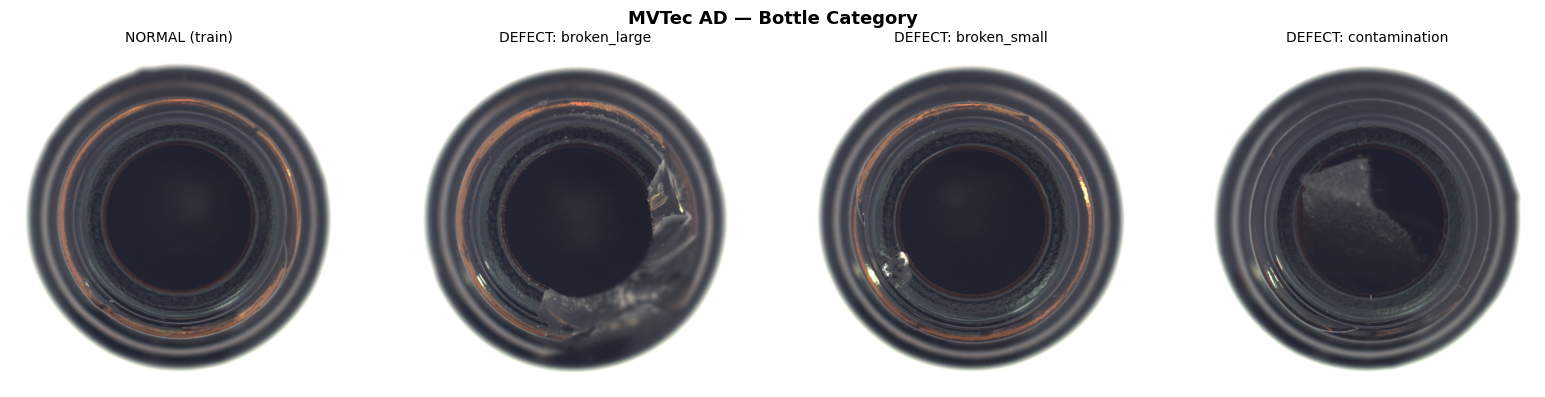

In [5]:
# ── Image reading helper ──────────────────────────────────────────────────────
def read_rgb(path):
    # cv2.imread() reads an image from disk and returns it as a NumPy array
    # PROBLEM: OpenCV uses BGR (Blue-Green-Red) channel order instead of RGB
    # cv2.cvtColor() converts the image from BGR to RGB,
    # which is what matplotlib expects for correct colour display
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

# ── Collect one sample image per category ─────────────────────────────────────
# Take the first normal image from the training set (index [0] after sorting)
samples = [sorted(glob.glob(os.path.join(train_dir, "*.png")))[0]]
titles  = ["NORMAL (train)"]

# Add one example for each defect type
for d in defect_types:
    p = sorted(glob.glob(os.path.join(test_dir, d, "*.png")))[0]
    samples.append(p)        # .append() adds one element to the end of the list
    titles.append(f"DEFECT: {d}")

# ── Build the multi-panel figure ──────────────────────────────────────────────
# plt.subplots(rows, cols) creates a grid of panels (axes)
# figsize=(width, height) sets the figure size in inches
fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))

# zip() pairs elements from multiple iterables one-by-one:
# e.g. zip([a,b],[1,2]) -> [(a,1),(b,2)]
for ax, path, title in zip(axes, samples, titles):
    ax.imshow(read_rgb(path))   # display the image in the current panel
    ax.set_title(title, fontsize=10)
    ax.axis("off")              # hide axes and tick numbers around the image

# Overall title for the whole figure
plt.suptitle("MVTec AD — Bottle Category", fontsize=13, fontweight="bold")
plt.tight_layout()  # automatically optimise spacing between panels
plt.show()          # render and display the figure

# Section 2 — Preprocessing

## Overview

Raw images cannot be fed directly into a neural network. The network has strict requirements
on input format, spatial dimensions, and value range. The preprocessing pipeline transforms
each image through a fixed sequence of operations that resolve three fundamental issues:

- **Dimension mismatch** — dataset images are 900×900 pixels; ResNet18 expects 224×224.
- **Format mismatch** — raw NumPy arrays must be converted to PyTorch tensors with channels-first layout.
- **Scale mismatch** — pixel values in [0, 255] must be normalized to match the statistical distribution seen during ResNet18's training on ImageNet.
Two separate pipelines are defined: one for training images (which includes data augmentation)
and one for test images (which does not).

---

## Pipeline Steps

### 1. Color Space Conversion: BGR → RGB

OpenCV loads images in **BGR** channel order by default. Since ResNet18 was trained on
RGB images, the channel order must be corrected before any further processing:

```python
cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
```

This operation swaps the first and third channel. Skipping it would cause the network
to receive systematically incorrect color information, corrupting all downstream features.

---

### 2. Resize to 224×224

```python
T.Resize((224, 224))
```

All images are resized to 224×224 pixels using bilinear interpolation. This is the
spatial resolution expected by ResNet18 and ensures uniform input dimensions across
the entire dataset. After this step, every image has shape `(224, 224, 3)`.

---

### 3. Data Augmentation — Random Horizontal Flip (training only)

```python
T.RandomHorizontalFlip(p=0.5)
```

During training, each image is flipped horizontally with probability 0.5. This is a
standard **data augmentation** technique: it artificially increases the variety of
training samples by exposing the model to mirror-image variants of the same scene,
without altering the semantic content (a normal bottle remains a normal bottle when flipped).

This step is intentionally **omitted from the test pipeline**. Test images must faithfully
represent real-world inputs; applying random transformations at test time would introduce


In [6]:
# ── ImageNet normalisation statistics ─────────────────────────────────────────
# ResNet18 was trained on ImageNet using these mean and standard deviation values
# for the three R, G, B channels. We must normalise our images the same way;
# otherwise the network "sees" value distributions different from what it learned on.
IMAGENET_MEAN = [0.485, 0.456, 0.406]   # per-channel means for R, G, B
IMAGENET_STD  = [0.229, 0.224, 0.225]   # per-channel standard deviations for R, G, B

# ── Transformation pipeline for TRAINING ──────────────────────────────────────
# T.Compose() takes a list of transforms and applies them sequentially,
# passing the output of one as the input to the next (like an assembly line)
train_transform = T.Compose([
    T.ToPILImage(),                           # NumPy array (H,W,3) -> PIL image (intermediate format)
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),        # resize every image to 224x224 pixels
    T.RandomHorizontalFlip(p=0.5),            # DATA AUGMENTATION: mirror the image horizontally
                                              # with 50% probability -> the network sees more variety
    T.ToTensor(),                             # PIL -> PyTorch tensor; scales values from [0,255] to [0.0,1.0]
                                              # and reorders axes from (H,W,C) to (C,H,W)
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # formula: x_norm = (x - mean) / std
])

# ── Transformation pipeline for TEST (no augmentation) ────────────────────────
# Test images must remain faithful to real inputs:
# we do not apply random flips (they would alter the image non-deterministically)
test_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Print the list of transforms in the training pipeline
print("Train transform pipeline:")
for t in train_transform.transforms:
    print(f"  {t}")

Train transform pipeline:
  ToPILImage()
  Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  RandomHorizontalFlip(p=0.5)
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


In [7]:
# ── Custom Dataset class ──────────────────────────────────────────────────────
# In PyTorch, to manage your own data you create a class that INHERITS from Dataset.
# "Inheriting" means our class gets all the functionality of Dataset
# and overrides / adds methods specific to our data.
class MVTecDataset(Dataset):
    """PyTorch Dataset for one MVTec AD category."""

    # __init__ is the "constructor": called when we create an instance of the class
    # (e.g. MVTecDataset(DATASET_ROOT, split="train", transform=train_transform))
    def __init__(self, root, split="train", transform=None):
        self.transform   = transform  # preprocessing pipeline to apply to each image
        self.image_paths = []  # list of paths to all images
        self.labels      = []  # 0 = normal, 1 = defective
        self.mask_paths  = []  # paths to ground-truth masks (None for normal images)

        if split == "train":
            # glob.glob() finds all .png files in the train/good folder
            for p in sorted(glob.glob(os.path.join(root, "train", "good", "*.png"))):
                self.image_paths.append(p)
                self.labels.append(0)        # all training images are normal
                self.mask_paths.append(None) # no mask for normal images
        else:
            # For the test set, iterate over all defect types (including "good")
            for defect_type in sorted(os.listdir(os.path.join(root, "test"))):
                img_dir  = os.path.join(root, "test", defect_type)
                mask_dir = os.path.join(root, "ground_truth", defect_type)
                # If the type is "good" -> label 0 (normal), otherwise 1 (defective)
                label    = 0 if defect_type == "good" else 1
                for p in sorted(glob.glob(os.path.join(img_dir, "*.png"))):
                    self.image_paths.append(p)
                    self.labels.append(label)
                    if label == 1:
                        # Build the path to the corresponding mask:
                        # os.path.basename() extracts just the file name from the full path
                        # .replace() substitutes one substring with another
                        mask_name = os.path.basename(p).replace(".png", "_mask.png")
                        self.mask_paths.append(os.path.join(mask_dir, mask_name))
                    else:
                        self.mask_paths.append(None)

    # __len__ tells PyTorch how many images are in the dataset.
    # DataLoader calls this internally to know when to stop iterating.
    def __len__(self):
        return len(self.image_paths)

    # __getitem__ retrieves a single sample by index (like list[i]).
    # PyTorch calls this method for every image it needs to load.
    def __getitem__(self, idx):
        # Read the image and convert from BGR to RGB
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        # Apply the transformation pipeline if provided, otherwise just convert to tensor
        img = self.transform(img) if self.transform else T.ToTensor()(img)

        # ── Load the ground-truth mask ─────────────────────────────────────────
        mask_path = self.mask_paths[idx]
        if mask_path and os.path.exists(mask_path):
            # IMREAD_GRAYSCALE reads the image as a single-channel grey-scale array
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            # Resize the mask to match the image dimensions
            mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
            # Convert to a binary mask: pixel > 0 -> 1 (defect), pixel = 0 -> 0 (normal)
            mask = (mask > 0).astype(np.uint8)
        else:
            # For normal images: all-zero mask (no defect)
            mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)

        # Return a tuple (image, label, mask)
        return img, self.labels[idx], mask

In [8]:
# ── Instantiate the datasets ──────────────────────────────────────────────────
# We create two MVTecDataset objects: one for training, one for testing
train_dataset = MVTecDataset(DATASET_ROOT, split="train", transform=train_transform)
test_dataset  = MVTecDataset(DATASET_ROOT, split="test",  transform=test_transform)

# ── Create the DataLoaders ────────────────────────────────────────────────────
# DataLoader wraps a Dataset and handles:
#   - loading data in batches of size batch_size
#   - optional random shuffling (shuffle=True)
#   - parallel loading with multiple worker processes (num_workers)
# batch_size=32: process 32 images at a time (balance between speed and GPU memory)
# shuffle=False: keep the original order (useful to align predictions with labels later)
# num_workers=2: 2 background processes prepare batches while the GPU processes the current one
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train : {len(train_dataset)} images")
# sum() on a list of 0s and 1s counts how many equal 1 (the defective images)
print(f"Test  : {len(test_dataset)} images  ({sum(test_dataset.labels)} defective)")

# ── Verify tensor shapes ──────────────────────────────────────────────────────
# iter() creates an iterator from the DataLoader; next() pulls the first element (first batch)
imgs, labels, masks = next(iter(train_loader))
print(f"\nBatch shapes:")
# .shape returns the tensor dimensions as a torch.Size object
# list() converts it to a plain list for easier reading
# Image shape: (batch_size=32, channels=3, height=224, width=224)
print(f"  Images : {list(imgs.shape)}   → (batch, channels, H, W)")
print(f"  Labels : {list(labels.shape)}")
print(f"  Masks  : {list(masks.shape)}")

Train : 209 images
Test  : 83 images  (63 defective)

Batch shapes:
  Images : [32, 3, 224, 224]   → (batch, channels, H, W)
  Labels : [32]
  Masks  : [32, 224, 224]


# Section 3 — Feature Extraction with ResNet18

## Motivation

Comparing images directly at the pixel level is not a viable strategy for anomaly detection.
A 224×224 RGB image contains 150,528 numerical values, and even minor variations in
lighting, position, or camera angle cause large pixel-level differences between otherwise
identical images. What is needed is a more abstract representation — a compact numerical
descriptor that captures *what* is present in an image, independently of low-level
pixel-level details.

This compact representation is called a **feature vector**, and the process of computing
it from raw image data is called **feature extraction**.

---

## Convolutional Neural Networks

A Convolutional Neural Network (CNN) is a sequence of layers, each of which transforms
its input into a progressively more abstract representation. The core operation is the
**convolution**: a small filter (e.g., 3×3 pixels) is slid across the entire spatial
extent of the input. At each position, the filter values are multiplied element-wise with
the corresponding input values and summed, producing a single scalar. The result is a
feature map that responds strongly where the input matches the filter's pattern.

Crucially, filter values are not hand-designed — they are **learned from data** during
training by minimizing a task-specific loss function. A network trained on large-scale
image classification therefore learns, in its early and intermediate layers, general-purpose
visual detectors: edges, textures, local patterns, and structural elements that are
universally useful for describing visual content.

---

## ResNet18 Architecture

ResNet18 is a CNN architecture introduced by He et al. (2015). The number 18 refers to
the count of layers with learnable parameters. For a 224×224 RGB input, the spatial
resolution and channel depth evolve through the network as follows:

| Stage | Output shape | Typical content |
|-------|-------------|-----------------|
| Input | (3, 224, 224) | Raw RGB pixels |
| conv1 + pool | (64, 56, 56) | Edges, intensity gradients |
| layer1 | (64, 56, 56) | Simple textures, corners |
| layer2 | (128, 28, 28) | Local patterns, repetitive structures |
| layer3 | (256, 14, 14) | Object parts, complex shapes |
| layer4 | (512, 7, 7) | High-level semantic concepts |
| fc | (1000,) | ImageNet class scores |

As depth increases, spatial resolution decreases and the number of channels grows.
Deeper layers capture increasingly abstract and class-specific information.

---

## Why Truncate at Layer2?

The network is truncated after `layer2`, discarding all subsequent layers including
the classification head. This design choice is motivated by two considerations: